In [1]:
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


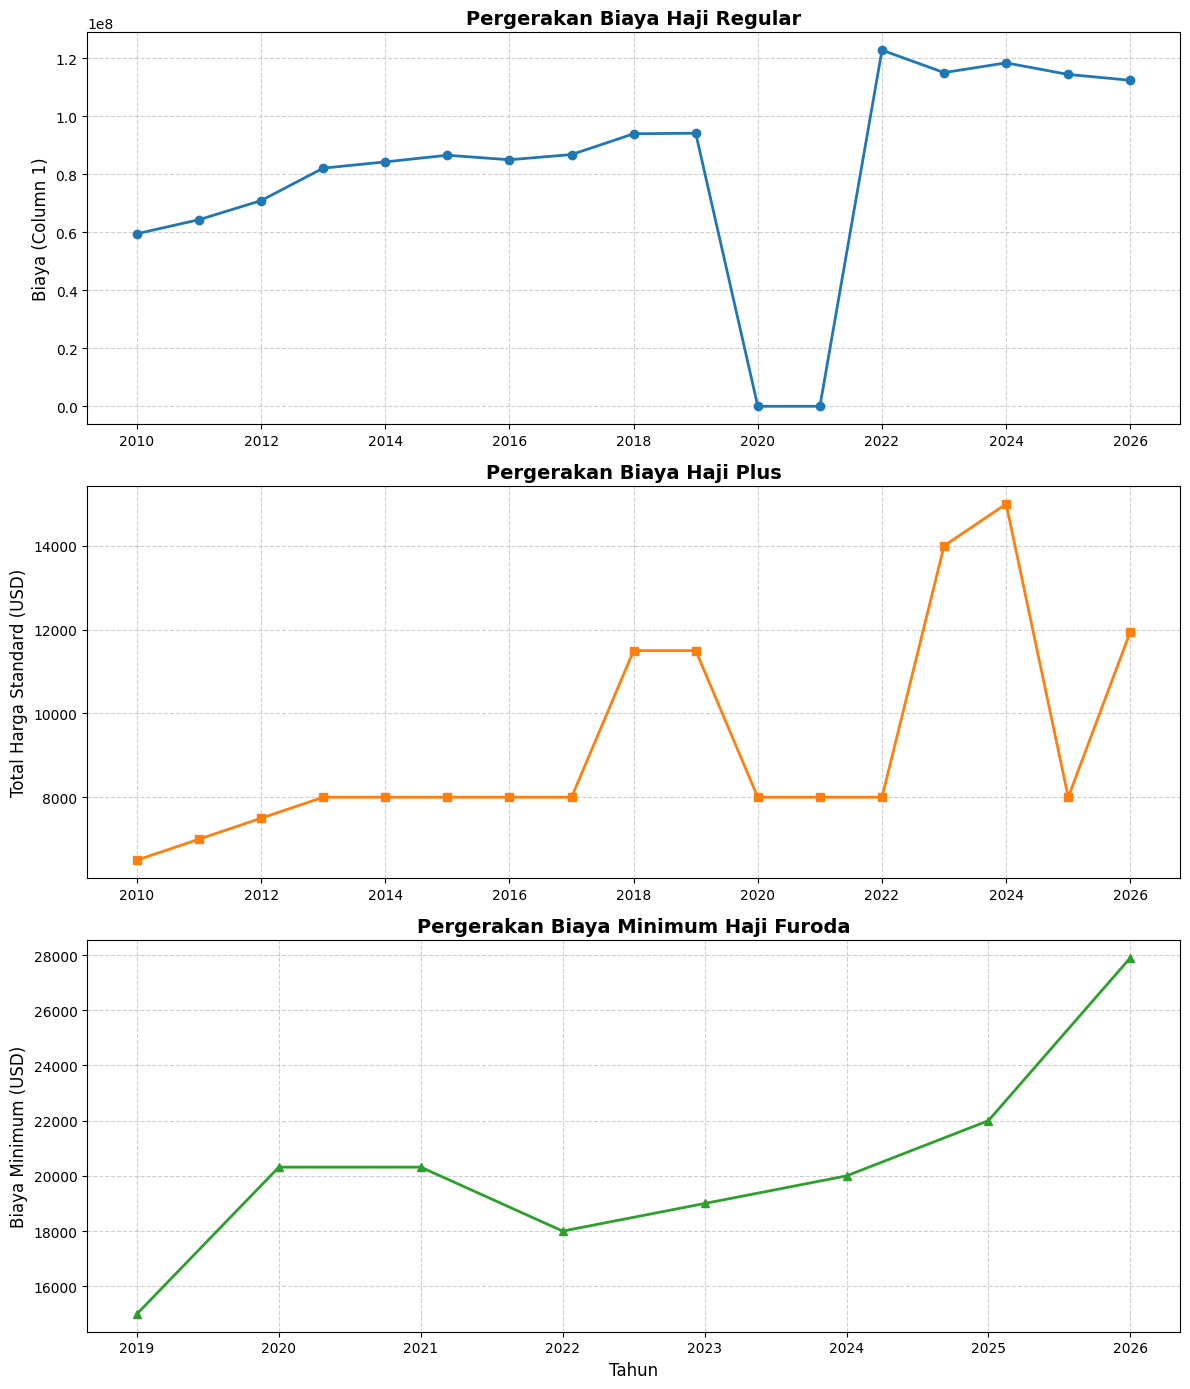

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membaca Data dari Excel
file_path = "Biaya Haji.xlsx"
df_regular = pd.read_excel(file_path, sheet_name="Regular")
df_haji_plus = pd.read_excel(file_path, sheet_name="Haji Plus")
df_haji_furoda = pd.read_excel(file_path, sheet_name="Haji Furoda")

# Menyimpan nama kolom ke dalam variabel agar lebih mudah
col_reg = "Column 1"
col_plus = "Total Harga Paket Standard (USD)"
col_furoda = "Biaya Minimum Paket (USD)"

# 2. Melakukan Imputasi Rata-rata (Mean Imputation) untuk nilai yang kosong (NaN)
df_regular[col_reg] = df_regular[col_reg].fillna(df_regular[col_reg].mean())
df_haji_plus[col_plus] = df_haji_plus[col_plus].fillna(df_haji_plus[col_plus].mean())
df_haji_furoda[col_furoda] = df_haji_furoda[col_furoda].fillna(df_haji_furoda[col_furoda].mean())

# Mengelompokkan data berdasarkan Tahun
timeline_reg = df_regular.groupby("Tahun Keberangkatan")[col_reg].mean()
timeline_plus = df_haji_plus.groupby("Tahun Penawaran")[col_plus].mean()
timeline_furoda = df_haji_furoda.groupby("Tahun Keberangkatan")[col_furoda].mean()

# 3. Visualisasi Data (Timeline) - Dipisah menjadi 3 Grafik
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Grafik 1: Haji Regular
axes[0].plot(timeline_reg.index, timeline_reg.values, marker="o", color="tab:blue", linewidth=2)
axes[0].set_title("Pergerakan Biaya Haji Regular", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Biaya (Column 1)", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Grafik 2: Haji Plus
axes[1].plot(timeline_plus.index, timeline_plus.values, marker="s", color="tab:orange", linewidth=2)
axes[1].set_title("Pergerakan Biaya Haji Plus", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Total Harga Standard (USD)", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.6)

# Grafik 3: Haji Furoda
axes[2].plot(timeline_furoda.index, timeline_furoda.values, marker="^", color="tab:green", linewidth=2)
axes[2].set_title("Pergerakan Biaya Minimum Haji Furoda", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Tahun", fontsize=12)
axes[2].set_ylabel("Biaya Minimum (USD)", fontsize=12)
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
